# Part 2 — FrozenLake-v1

### Environment Setup
Run the following in your terminal:
```
conda activate rl-bandits
```

### Imports

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

# Device selection
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.10.0
Device: mps


### Environment Exploration

In [23]:
env = gym.make('FrozenLake-v1', is_slippery=True, render_mode='ansi')

print(f"Observation Space: {env.observation_space}")
print(f"  Type: {type(env.observation_space).__name__}")
print(f"  n (number of states): {env.observation_space.n}")
print()
print(f"Action Space: {env.action_space}")
print(f"  Type: {type(env.action_space).__name__}")
print(f"  n (number of actions): {env.action_space.n}")
print(f"  Actions: 0=Left, 1=Down, 2=Right, 3=Up")
print()

obs, info = env.reset(seed=42)
print(f"Initial observation: {obs}")
print(f"Info: {info}")
print()
print(env.render())

Observation Space: Discrete(16)
  Type: Discrete
  n (number of states): 16

Action Space: Discrete(4)
  Type: Discrete
  n (number of actions): 4
  Actions: 0=Left, 1=Down, 2=Right, 3=Up

Initial observation: 0
Info: {'prob': 1}


SFFF
FHFH
FFFH
HFFG



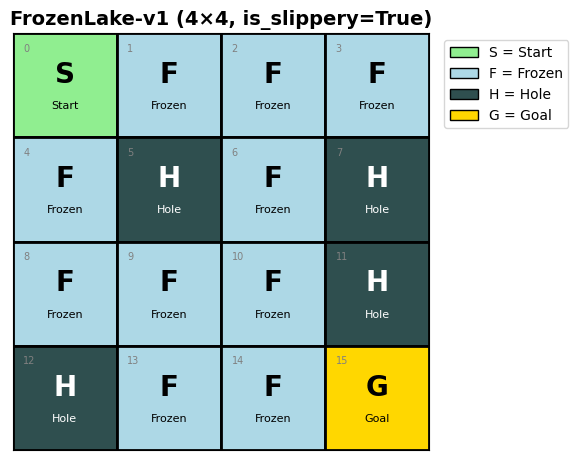

In [24]:
# Visualize the FrozenLake grid
desc = env.unwrapped.desc.astype(str)
nrow, ncol = desc.shape

color_map = {'S': '#90EE90', 'F': '#ADD8E6', 'H': '#2F4F4F', 'G': '#FFD700'}
label_map = {'S': 'Start', 'F': 'Frozen', 'H': 'Hole', 'G': 'Goal'}

fig, ax = plt.subplots(figsize=(6, 6))

for i in range(nrow):
    for j in range(ncol):
        cell = desc[i][j]
        color = color_map[cell]
        text_color = 'white' if cell == 'H' else 'black'
        ax.add_patch(plt.Rectangle((j, nrow - 1 - i), 1, 1, facecolor=color, edgecolor='black', linewidth=2))
        ax.text(j + 0.5, nrow - 1 - i + 0.6, cell, ha='center', va='center',
                fontsize=20, fontweight='bold', color=text_color)
        ax.text(j + 0.5, nrow - 1 - i + 0.3, label_map[cell], ha='center', va='center',
                fontsize=8, color=text_color)
        # State number
        state = i * ncol + j
        ax.text(j + 0.1, nrow - 1 - i + 0.9, str(state), ha='left', va='top',
                fontsize=7, color='gray')

ax.set_xlim(0, ncol)
ax.set_ylim(0, nrow)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('FrozenLake-v1 (4×4, is_slippery=True)', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[k], edgecolor='black', label=f'{k} = {label_map[k]}') for k in ['S', 'F', 'H', 'G']]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.35, 1.0))

plt.tight_layout()
plt.show()

### MDP Mapping

| MDP Component | Mathematical Notation | FrozenLake-v1 Gymnasium Mapping |
|---|---|---|
| **States (S)** | $S \in \{0, 1, ..., 15\}$ | 16 discrete states (4x4 grid). Each state is an integer representing position. |
| **Actions (A)** | $A \in \{0, 1, 2, 3\}$ | 4 discrete actions: Left(0), Down(1), Right(2), Up(3) |
| **Rewards (R)** | $R \in \{0, 1\}$ | +1 for reaching the goal (state 15), 0 otherwise |
| **Transition (P)** | $p(s', r \mid s, a)$ | Stochastic when `is_slippery=True` — agent slips to adjacent directions with probability 1/3 each. Deterministic when `is_slippery=False`. |
| **Discount (γ)** | $\gamma \in [0, 1]$ | Not set by the environment — chosen by the agent/algorithm |

### Random Agent

In [25]:
class RandomAgent:
    def __init__(self, env):
        self.action_space = env.action_space

    def select_action(self, obs=None):
        return self.action_space.sample()

### Performance Measurement

In [26]:
def run_episodes(env, agent, n_episodes=1000, seed=42):
    total_rewards = []
    episode_lengths = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0
        steps = 0
        done = False

        while not done:
            action = agent.select_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
            done = terminated or truncated

        total_rewards.append(total_reward)
        episode_lengths.append(steps)

    return total_rewards, episode_lengths


agent = RandomAgent(env)
rewards, lengths = run_episodes(env, agent, n_episodes=1000)

print(f"Results over 1000 episodes:")
print(f"  Success rate: {np.mean([r > 0 for r in rewards]) * 100:.1f}%")
print(f"  Average reward: {np.mean(rewards):.4f}")
print(f"  Average episode length: {np.mean(lengths):.1f} steps")

Results over 1000 episodes:
  Success rate: 1.5%
  Average reward: 0.0150
  Average episode length: 7.9 steps


In [27]:
# Detailed Quantitative Summary
rewards_arr = np.array(rewards)
lengths_arr = np.array(lengths)
successes = rewards_arr > 0

print("=" * 55)
print("FrozenLake-v1 — Random Agent Summary (1000 episodes)")
print("=" * 55)

print(f"\n--- Reward Statistics ---")
print(f"  Success rate:       {successes.mean() * 100:.2f}%")
print(f"  Total successes:    {successes.sum()} / {len(rewards)}")
print(f"  Average reward:     {rewards_arr.mean():.4f}")
print(f"  Std dev reward:     {rewards_arr.std():.4f}")

print(f"\n--- Episode Length Statistics ---")
print(f"  Average length:     {lengths_arr.mean():.2f} steps")
print(f"  Median length:      {np.median(lengths_arr):.1f} steps")
print(f"  Std dev length:     {lengths_arr.std():.2f} steps")
print(f"  Min length:         {lengths_arr.min()} steps")
print(f"  Max length:         {lengths_arr.max()} steps")

print(f"\n--- Success vs. Failure Breakdown ---")
if successes.sum() > 0:
    print(f"  Avg length (success): {lengths_arr[successes].mean():.1f} steps")
print(f"  Avg length (failure): {lengths_arr[~successes].mean():.1f} steps")

print("=" * 55)

FrozenLake-v1 — Random Agent Summary (1000 episodes)

--- Reward Statistics ---
  Success rate:       1.50%
  Total successes:    15 / 1000
  Average reward:     0.0150
  Std dev reward:     0.1216

--- Episode Length Statistics ---
  Average length:     7.88 steps
  Median length:      6.0 steps
  Std dev length:     5.93 steps
  Min length:         2 steps
  Max length:         50 steps

--- Success vs. Failure Breakdown ---
  Avg length (success): 13.5 steps
  Avg length (failure): 7.8 steps


Saved frozen_lake_results.png


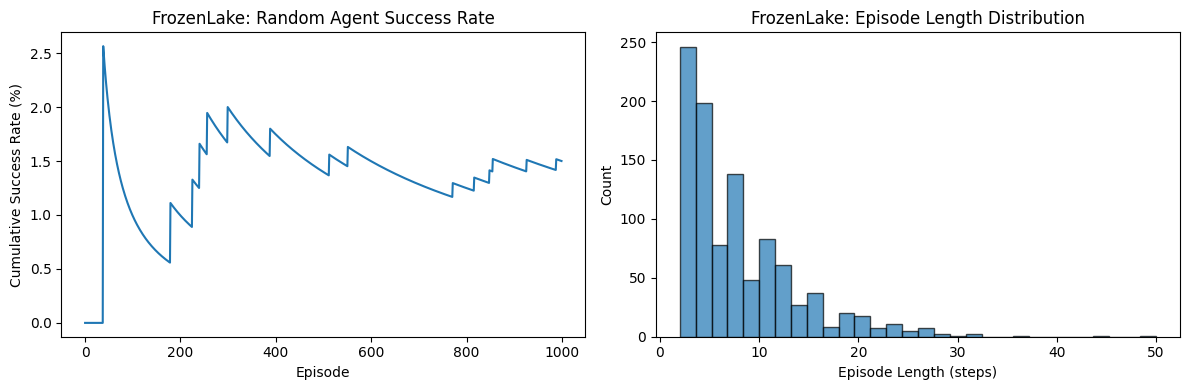

In [28]:
# Plot and save results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

successes = np.array([r > 0 for r in rewards], dtype=float)
cumulative_success = np.cumsum(successes) / (np.arange(len(successes)) + 1) * 100
ax1.plot(cumulative_success)
ax1.set_xlabel('Episode')
ax1.set_ylabel('Cumulative Success Rate (%)')
ax1.set_title('FrozenLake: Random Agent Success Rate')

ax2.hist(lengths, bins=30, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Episode Length (steps)')
ax2.set_ylabel('Count')
ax2.set_title('FrozenLake: Episode Length Distribution')

plt.tight_layout()
fig.savefig('frozen_lake_results.png', dpi=150)
print("Saved frozen_lake_results.png")
plt.show()